In [10]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
DATA_PATH = Path('..', 'Dataset', 'pre-processed', 'final_preprocessed_good_data.csv')
BAD_DATA_PATH = Path('..','Dataset', 'processed_402_R_faulty.csv')
DATA_PATH.exists(),BAD_DATA_PATH.exists()

(True, True)

In [7]:
good_df = pd.read_csv(DATA_PATH)
bad_df = pd.read_csv(BAD_DATA_PATH)

/tmp/ipykernel_154624/3657093414.py:1: DtypeWarning: Columns (0: CH3 Resistance Break, 1: CH4 Resistance Break, 2: CH3 Bounce Break, 3: CH4 Bounce Break, 4: CH1 Resistance Break, 5: CH2 Resistance Break, 6: CH1 Bounce Break, 7: CH2 Bounce Break) have mixed types. Specify dtype option on import or set low_memory=False.
  good_df = pd.read_csv(DATA_PATH)


In [8]:
good_df.head()

,Coil Current C1 (A),Coil Current C2 (A),Coil Current C3 (A),Coil Current C4 (A),Coil Current C5 (A),Coil Current C6 (A),Contact Travel T1 (mm),Contact Travel T2 (mm),Contact Travel T3 (mm),Contact Travel T4 (mm),...,phase,CH3 Resistance Break,CH4 Resistance Break,CH3 Bounce Break,CH4 Bounce Break,breaker_id,CH1 Resistance Break,CH2 Resistance Break,CH1 Bounce Break,CH2 Bounce Break
0,0.000,0.000,0.000,0.029,0.0,0.0,0.0,0.0,0.0,0.85,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN
1,0.000,0.000,0.000,0.037,0.0,0.0,0.0,0.0,0.0,-0.26,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN
2,0.000,0.000,0.000,0.051,0.0,0.0,0.0,0.0,0.0,-0.02,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN
3,0.029,0.044,0.037,0.029,0.0,0.0,0.0,0.0,0.0,0.14,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN
4,0.066,0.073,0.066,0.051,0.0,0.0,0.0,0.0,0.0,-0.02,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN


In [9]:
good_df.columns

Index(['Coil Current C1 (A)', 'Coil Current C2 (A)', 'Coil Current C3 (A)',
       'Coil Current C4 (A)', 'Coil Current C5 (A)', 'Coil Current C6 (A)',
       'Contact Travel T1 (mm)', 'Contact Travel T2 (mm)',
       'Contact Travel T3 (mm)', 'Contact Travel T4 (mm)',
       'Contact Travel T5 (mm)', 'Contact Travel T6 (mm)',
       'DCRM Res CH1 in uOhm', 'DCRM Current CH1 in Amp',
       'CH1 Close-Velocity (m/s)', 'CH1 Open-Velocity (m/s)', 'CH1 Test Run',
       'DCRM Res CH2 in uOhm', 'DCRM Current CH2 in Amp',
       'CH2 Close-Velocity (m/s)', 'CH2 Open-Velocity (m/s)', 'CH2 Test Run',
       'DCRM Res CH3 in uOhm', 'DCRM Current CH3 in Amp',
       'CH3 Close-Velocity (m/s)', 'CH3 Open-Velocity (m/s)', 'CH3 Test Run',
       'DCRM Res CH4 in uOhm', 'DCRM Current CH4 in Amp',
       'CH4 Close-Velocity (m/s)', 'CH4 Open-Velocity (m/s)', 'CH4 Test Run',
       'DCRM Res CH5 in uOhm', 'DCRM Current CH5 in Amp',
       'CH5 Close-Velocity (m/s)', 'CH5 Open-Velocity (m/s)', 'CH5 Te

In [57]:
bad_df.head()

,Coil Current C1 (A),Coil Current C2 (A),Coil Current C3 (A),Coil Current C4 (A),Coil Current C5 (A),Coil Current C6 (A),Contact Travel T1 (mm),Contact Travel T2 (mm),Contact Travel T3 (mm),Contact Travel T4 (mm),...,DCRM Current CH6 in Amp,CH6 Close-Velocity (m/s),CH6 Open-Velocity (m/s),CH6 Test Run,CH3 Bounce Break,CH4 Bounce Break,CH1 Resistance Break,CH2 Resistance Break,CH1 Bounce Break,CH2 Bounce Break
0,0.015,0.029,0.015,0.029,0.0,0.0,0,0,0,0.10,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN
1,0.007,0.022,0.000,0.037,0.0,0.0,0,0,0,-0.06,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN
2,0.051,0.007,0.000,0.066,0.0,0.0,0,0,0,0.02,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN
3,0.161,0.029,0.000,0.051,0.0,0.0,0,0,0,0.10,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN
4,0.286,0.022,0.015,0.029,0.0,0.0,0,0,0,0.18,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
list(set(good_df) - set(bad_df)),
list(set(bad_df) - set(good_df))


['phase']

In [25]:
bad_df.columns

Index(['Coil Current C1 (A)', 'Coil Current C2 (A)', 'Coil Current C3 (A)',
       'Coil Current C4 (A)', 'Coil Current C5 (A)', 'Coil Current C6 (A)',
       'Contact Travel T1 (mm)', 'Contact Travel T2 (mm)',
       'Contact Travel T3 (mm)', 'Contact Travel T4 (mm)',
       'Contact Travel T5 (mm)', 'Contact Travel T6 (mm)',
       'DCRM Res CH1 in uOhm', 'DCRM Current CH1 in Amp',
       'CH1 Close-Velocity (m/s)', 'CH1 Open-Velocity (m/s)', 'CH1 Test Run',
       'DCRM Res CH2 in uOhm', 'DCRM Current CH2 in Amp',
       'CH2 Close-Velocity (m/s)', 'CH2 Open-Velocity (m/s)', 'CH2 Test Run',
       'DCRM Res CH3 in uOhm', 'DCRM Current CH3 in Amp',
       'CH3 Close-Velocity (m/s)', 'CH3 Open-Velocity (m/s)', 'CH3 Test Run',
       'CH3 Resistance Break', 'DCRM Res CH4 in uOhm',
       'DCRM Current CH4 in Amp', 'CH4 Close-Velocity (m/s)',
       'CH4 Open-Velocity (m/s)', 'CH4 Test Run', 'CH4 Resistance Break',
       'DCRM Res CH5 in uOhm', 'DCRM Current CH5 in Amp',
       'CH5 Cl

In [ ]:
cols = ['Coil Current C1 (A)', 'Coil Current C2 (A)', 'Coil Current C3 (A)',
       'Coil Current C4 (A)', 'Coil Current C5 (A)', 'Coil Current C6 (A)',
       'Contact Travel T1 (mm)', 'Contact Travel T2 (mm)',
       'Contact Travel T3 (mm)', 'Contact Travel T4 (mm)',
       'Contact Travel T5 (mm)', 'Contact Travel T6 (mm)',
       'DCRM Res CH1 in uOhm', 'DCRM Current CH1 in Amp',
       'CH1 Close-Velocity (m/s)', 'CH1 Open-Velocity (m/s)', 'CH1 Test Run',
       'DCRM Res CH2 in uOhm', 'DCRM Current CH2 in Amp',
       'CH2 Close-Velocity (m/s)', 'CH2 Open-Velocity (m/s)', 'CH2 Test Run',
       'DCRM Res CH3 in uOhm', 'DCRM Current CH3 in Amp',
       'CH3 Close-Velocity (m/s)', 'CH3 Open-Velocity (m/s)', 'CH3 Test Run',
       'CH3 Resistance Break', 'DCRM Res CH4 in uOhm',
       'DCRM Current CH4 in Amp', 'CH4 Close-Velocity (m/s)',
       'CH4 Open-Velocity (m/s)', 'CH4 Test Run', 'CH4 Resistance Break',
       'DCRM Res CH5 in uOhm', 'DCRM Current CH5 in Amp',
       'CH5 Close-Velocity (m/s)', 'CH5 Open-Velocity (m/s)', 'CH5 Test Run',
       'DCRM Res CH6 in uOhm', 'DCRM Current CH6 in Amp',
       'CH6 Close-Velocity (m/s)', 'CH6 Open-Velocity (m/s)', 'CH6 Test Run',
       'CH3 Bounce Break',
 'CH4 Bounce Break',
 'CH1 Bounce Break',
 'CH1 Resistance Break',
 'CH2 Resistance Break',
 'CH2 Bounce Break']

add_cols = []
for col in cols:
    if col in good_df.columns and col in bad_df.columns:
        print(None)
        continue
    else:
        print(f"Column '{col}' is missing in BAD DataFrame.")
        add_cols.append(col)

None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None


In [60]:
good_df['CH1 Resistance Break'].unique()

<StringArray>
[nan, 'RBreak1']
Length: 2, dtype: str

In [ ]:
import numpy as np

bad_df[['CH3 Bounce Break',
 'CH4 Bounce Break',
 'CH1 Bounce Break',
 'CH1 Resistance Break',
 'breaker_id',
 'phase',
 'CH2 Resistance Break',
 'CH2 Bounce Break']] = np.nan



In [62]:
bad_df.head()

,Coil Current C1 (A),Coil Current C2 (A),Coil Current C3 (A),Coil Current C4 (A),Coil Current C5 (A),Coil Current C6 (A),Contact Travel T1 (mm),Contact Travel T2 (mm),Contact Travel T3 (mm),Contact Travel T4 (mm),...,DCRM Current CH6 in Amp,CH6 Close-Velocity (m/s),CH6 Open-Velocity (m/s),CH6 Test Run,CH3 Bounce Break,CH4 Bounce Break,CH1 Resistance Break,CH2 Resistance Break,CH1 Bounce Break,CH2 Bounce Break
0,0.015,0.029,0.015,0.029,0.0,0.0,0,0,0,0.10,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN
1,0.007,0.022,0.000,0.037,0.0,0.0,0,0,0,-0.06,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN
2,0.051,0.007,0.000,0.066,0.0,0.0,0,0,0,0.02,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN
3,0.161,0.029,0.000,0.051,0.0,0.0,0,0,0,0.10,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN
4,0.286,0.022,0.015,0.029,0.0,0.0,0,0,0,0.18,...,0,0,0.12,TR4,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
list(set(good_df.columns) - set(bad_df.columns))

[]

In [64]:
for col in good_df.select_dtypes(include=['object']).columns:
    good_df[col] = LabelEncoder().fit_transform(good_df[col].astype(str))
    print(f"Encoded column: {col}")

Encoded column: CH1 Test Run
Encoded column: CH2 Test Run
Encoded column: CH3 Test Run
Encoded column: CH4 Test Run
Encoded column: CH5 Test Run
Encoded column: CH6 Test Run
Encoded column: CH3 Resistance Break
Encoded column: CH4 Resistance Break
Encoded column: CH3 Bounce Break
Encoded column: CH4 Bounce Break
Encoded column: CH1 Resistance Break
Encoded column: CH2 Resistance Break
Encoded column: CH1 Bounce Break
Encoded column: CH2 Bounce Break


/tmp/ipykernel_154624/1396465431.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in good_df.select_dtypes(include=['object']).columns:


In [65]:
for col in bad_df.select_dtypes(include=['object']).columns:
    bad_df[col] = LabelEncoder().fit_transform(bad_df[col].astype(str))
    print(f"Encoded column: {col}")

Encoded column: CH1 Test Run
Encoded column: CH2 Test Run
Encoded column: CH3 Test Run
Encoded column: CH3 Resistance Break
Encoded column: CH4 Test Run
Encoded column: CH4 Resistance Break
Encoded column: CH5 Test Run
Encoded column: CH6 Test Run


/tmp/ipykernel_154624/3777508448.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in bad_df.select_dtypes(include=['object']).columns:


In [66]:
good_df.dtypes.value_counts() 

float64    28
int64      22
Name: count, dtype: int64

In [67]:
bad_df.dtypes.info

<bound method Series.info of Coil Current C1 (A)         float64
Coil Current C2 (A)         float64
Coil Current C3 (A)         float64
Coil Current C4 (A)         float64
Coil Current C5 (A)         float64
Coil Current C6 (A)         float64
Contact Travel T1 (mm)        int64
Contact Travel T2 (mm)        int64
Contact Travel T3 (mm)        int64
Contact Travel T4 (mm)      float64
Contact Travel T5 (mm)        int64
Contact Travel T6 (mm)        int64
DCRM Res CH1 in uOhm          int64
DCRM Current CH1 in Amp       int64
CH1 Close-Velocity (m/s)      int64
CH1 Open-Velocity (m/s)     float64
CH1 Test Run                  int64
DCRM Res CH2 in uOhm          int64
DCRM Current CH2 in Amp       int64
CH2 Close-Velocity (m/s)      int64
CH2 Open-Velocity (m/s)     float64
CH2 Test Run                  int64
DCRM Res CH3 in uOhm        float64
DCRM Current CH3 in Amp     float64
CH3 Close-Velocity (m/s)    float64
CH3 Open-Velocity (m/s)     float64
CH3 Test Run                  int64

In [ ]:
bad_df[['CH3 Bounce Break',
 'CH4 Bounce Break',
 'CH1 Bounce Break',
 'CH1 Resistance Break',
 'CH2 Resistance Break',
 'CH2 Bounce Break']].astype('int64', errors='ignore')

,CH3 Bounce Break,CH4 Bounce Break,CH1 Bounce Break,CH1 Resistance Break,breaker_id,CH2 Resistance Break,CH2 Bounce Break
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
4495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
X_good = good_df.select_dtypes(include=[np.number])
X_faulty = bad_df.select_dtypes(include=[np.number])


In [70]:
common_cols = list(set(X_good.columns) & set(X_faulty.columns))
X_good = X_good[common_cols]
X_faulty = X_faulty[common_cols]

print(common_cols)

['Contact Travel T3 (mm)', 'DCRM Current CH3 in Amp', 'Coil Current C5 (A)', 'DCRM Res CH4 in uOhm', 'DCRM Res CH1 in uOhm', 'CH5 Open-Velocity (m/s)', 'DCRM Current CH6 in Amp', 'CH2 Resistance Break', 'DCRM Current CH1 in Amp', 'DCRM Current CH5 in Amp', 'CH4 Close-Velocity (m/s)', 'CH1 Resistance Break', 'CH1 Test Run', 'CH1 Close-Velocity (m/s)', 'DCRM Current CH2 in Amp', 'CH1 Bounce Break', 'DCRM Res CH5 in uOhm', 'CH2 Test Run', 'DCRM Res CH6 in uOhm', 'Coil Current C6 (A)', 'CH1 Open-Velocity (m/s)', 'DCRM Res CH3 in uOhm', 'CH3 Close-Velocity (m/s)', 'CH3 Bounce Break', 'CH4 Test Run', 'Contact Travel T4 (mm)', 'CH3 Test Run', 'CH3 Open-Velocity (m/s)', 'DCRM Current CH4 in Amp', 'CH3 Resistance Break', 'CH4 Resistance Break', 'Contact Travel T2 (mm)', 'DCRM Res CH2 in uOhm', 'Coil Current C3 (A)', 'CH4 Bounce Break', 'Contact Travel T5 (mm)', 'CH5 Test Run', 'Coil Current C2 (A)', 'CH6 Open-Velocity (m/s)', 'Contact Travel T6 (mm)', 'Coil Current C1 (A)', 'Coil Current C4 (A)

In [71]:
print(f"Good data shape  : {X_good.shape}")
print(f"Faulty data shape: {X_faulty.shape}")
print(f"Features         : {len(common_cols)}")

Good data shape  : (49500, 50)
Faulty data shape: (4500, 50)
Features         : 50


In [72]:
X_train, X_test_good = train_test_split(X_good, test_size=0.2, random_state=42)


Was messing with the parameters and unfortunately broke some things!. Though the model contaminations are listed in README.md

In [ ]:
for contamination in [0.15, 0.16, 0.17, 0.18, 0.19, 0.20,0.22,0.25]:
    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train)
    
    y_pred_faulty = model.predict(X_faulty)
    y_pred_good = model.predict(X_test_good)
    
    detected = (y_pred_faulty == -1).sum()
    false_alarms = (y_pred_good == -1).sum()
    
    print(f"Contamination {contamination:.2f} → "
          f"Detected: {detected/len(X_faulty)*100:.1f}% | "
          f"False Alarms: {false_alarms/len(X_test_good)*100:.1f}%")

Contamination 0.15 → Detected: 22.2% | False Alarms: 15.0%
Contamination 0.16 → Detected: 24.5% | False Alarms: 16.1%
Contamination 0.17 → Detected: 28.3% | False Alarms: 17.2%
Contamination 0.18 → Detected: 31.6% | False Alarms: 18.2%
Contamination 0.19 → Detected: 34.9% | False Alarms: 19.1%
Contamination 0.20 → Detected: 39.2% | False Alarms: 20.3%
Contamination 0.22 → Detected: 43.6% | False Alarms: 22.4%
Contamination 0.25 → Detected: 49.4% | False Alarms: 25.4%
Contamination 0.30 → Detected: 63.3% | False Alarms: 30.4%
Contamination 0.40 → Detected: 77.7% | False Alarms: 40.5%
Contamination 0.50 → Detected: 100.0% | False Alarms: 50.6%


This is the old model with 52 params, above i was checking model results with less params

In [100]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.22,
    random_state=42,
    n_jobs=-1
    )
model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.22
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [101]:
y_pred_good = model.predict(X_test_good)

# Predict on faulty data → should be anomaly (-1)
y_pred_faulty = model.predict(X_faulty)

# Results
print(f"\nGood data predictions:")
print(f"  Normal  (1) : {(y_pred_good == 1).sum()}")   # should be high
print(f"  Anomaly (-1): {(y_pred_good == -1).sum()}") 


Good data predictions:
  Normal  (1) : 7714
  Anomaly (-1): 2186


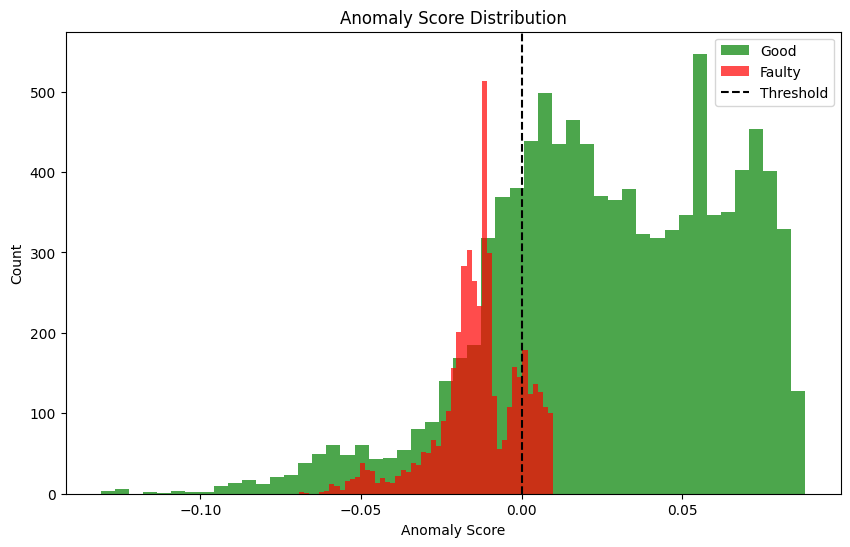

In [102]:
import matplotlib.pyplot as plt

scores_good = model.decision_function(X_test_good)
scores_faulty = model.decision_function(X_faulty)

plt.figure(figsize=(10, 6))
plt.hist(scores_good, bins=50, alpha=0.7, label='Good', color='green')
plt.hist(scores_faulty, bins=50, alpha=0.7, label='Faulty', color='red')
plt.axvline(x=0, color='black', linestyle='--', label='Threshold')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.title('Anomaly Score Distribution')
plt.legend()
plt.savefig('anomaly_score_distribution.png')
plt.show()

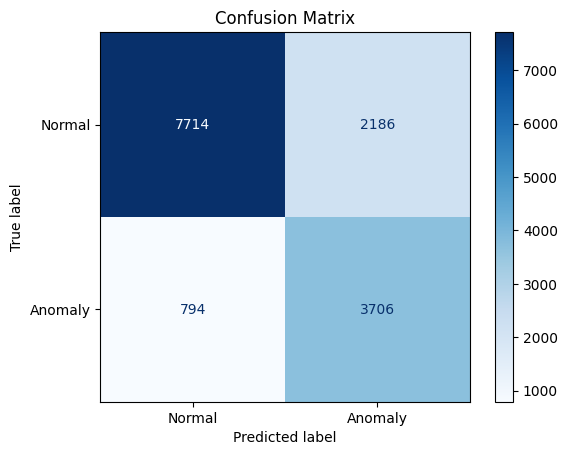

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay

y_true = [0] * len(X_test_good) + [1] * len(X_faulty)
y_pred = list((model.predict(X_test_good) == -1).astype(int)) + \
         list((model.predict(X_faulty) == -1).astype(int))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

/home/mushman/Downloads/DCRM_analysis /.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


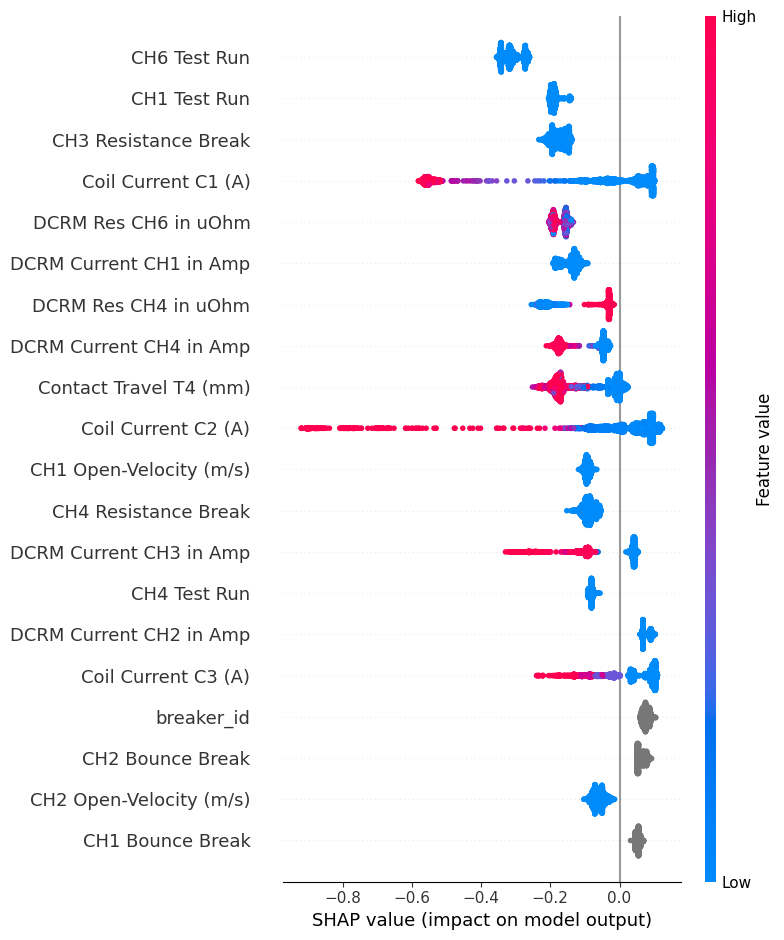

In [105]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_faulty)
shap.summary_plot(shap_values, X_faulty)

/tmp/ipykernel_18347/73516006.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores_good, scores_faulty], labels=['Good', 'Faulty'])


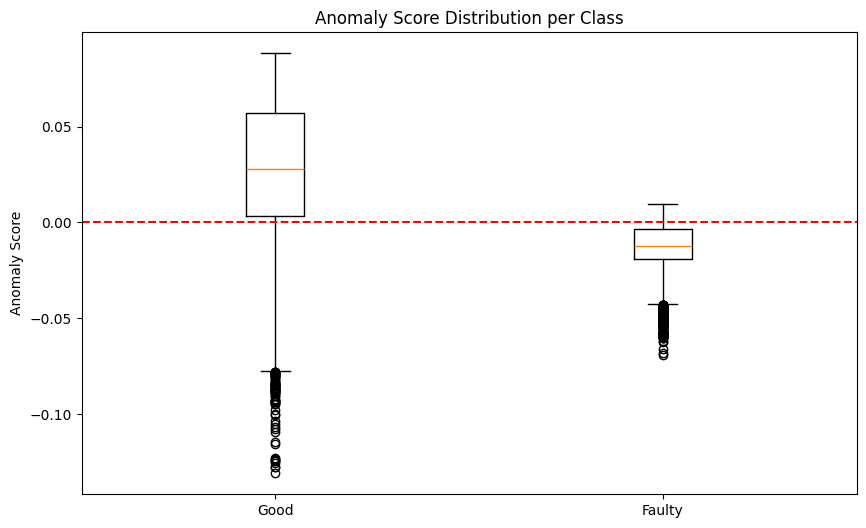

In [118]:
plt.figure(figsize=(10, 6))
plt.boxplot([scores_good, scores_faulty], labels=['Good', 'Faulty'])
plt.axhline(y=0, color='red', linestyle='--', label='Threshold')
plt.ylabel('Anomaly Score')
plt.title('Anomaly Score Distribution per Class')
plt.savefig('boxplot.png')
plt.show()

In [104]:
import joblib
joblib.dump(model, 'isolation_forest_final_final.pkl')
print("Model saved successfully.")

Model saved successfully.


In [85]:
def map_to_component(feature_name):
    feature_lower = feature_name.lower()
    
    if any(x in feature_lower for x in ['phase', 'breaker_id']):
        return 'Metadata'
    elif 'test run' in feature_lower:
        return 'Test Configuration'
    elif 'coil current' in feature_lower:
        return 'Operating Coil/Mechanism'  
    elif 'dcrm current' in feature_lower:
        return 'Measurement Current'        # ← fixed
    elif any(x in feature_lower for x in ['close-velocity', 'close velocity']):
        return 'Closing Mechanism'
    elif any(x in feature_lower for x in ['open-velocity', 'open velocity']):
        return 'Opening/Spring Mechanism'
    elif 'dcrm res' in feature_lower:
        return 'Contact Surface'            # ← more specific
    elif any(x in feature_lower for x in ['travel']):
        return 'Mechanical Linkage'
    elif any(x in feature_lower for x in ['bounce', 'bb']):
        return 'Contact Spring'
    elif 'resistance break' in feature_lower:
        return 'Contact Integrity'
    else:
        return f'Unknown ({feature_name})'

In [86]:
print("Feature → Component mapping:")
for feature in X_faulty.columns.tolist():
    print(f"  {feature} → {map_to_component(feature)}")

Feature → Component mapping:
  Coil Current C4 (A) → Operating Coil/Mechanism
  Contact Travel T6 (mm) → Mechanical Linkage
  CH6 Test Run → Test Configuration
  CH1 Open-Velocity (m/s) → Opening/Spring Mechanism
  DCRM Res CH5 in uOhm → Contact Surface
  CH5 Test Run → Test Configuration
  CH2 Bounce Break → Contact Spring
  CH4 Open-Velocity (m/s) → Opening/Spring Mechanism
  DCRM Current CH6 in Amp → Measurement Current
  Contact Travel T1 (mm) → Mechanical Linkage
  DCRM Current CH2 in Amp → Measurement Current
  CH3 Close-Velocity (m/s) → Closing Mechanism
  CH2 Resistance Break → Contact Integrity
  CH3 Open-Velocity (m/s) → Opening/Spring Mechanism
  CH4 Resistance Break → Contact Integrity
  CH2 Close-Velocity (m/s) → Closing Mechanism
  DCRM Current CH5 in Amp → Measurement Current
  CH2 Test Run → Test Configuration
  CH3 Bounce Break → Contact Spring
  CH3 Resistance Break → Contact Integrity
  Coil Current C1 (A) → Operating Coil/Mechanism
  CH2 Open-Velocity (m/s) → Openin

In [93]:
import shap 

def generate_diagnosis(model, sample, feature_names, top_n=5):
    explainer = shap.KernelExplainer(model.decision_function, X_train[:100])
    shap_values = explainer.shap_values(sample)
    
    feature_importance = pd.DataFrame({
        'feature'   : feature_names,
        'shap_value': shap_values[0],
        'direction' : ['anomalous' if v < 0 else 'normal' for v in shap_values[0]]
    }).sort_values('shap_value', ascending=True)
    
    feature_importance['component'] = feature_importance['feature'].apply(map_to_component)
    
    # Filter out metadata and test config from top features too
    filtered = feature_importance[
        ~feature_importance['component'].isin(['Metadata', 'Test Configuration'])
    ]
    
    anomalous = filtered[filtered['direction'] == 'anomalous']
    component_diagnosis = anomalous.groupby('component')['shap_value'].mean().sort_values()
    
    return filtered.head(top_n), component_diagnosis

In [94]:
# Find most anomalous sample
scores = model.decision_function(X_faulty)
most_anomalous_idx = scores.argmin()  # lowest score = most anomalous
print(f"Most anomalous sample index: {most_anomalous_idx}")
print(f"Anomaly score: {scores[most_anomalous_idx]:.3f}")

# Run diagnosis on most anomalous sample
top_features, components = generate_diagnosis(
    model,
    X_faulty.iloc[[most_anomalous_idx]],
    X_faulty.columns.tolist()
)

Most anomalous sample index: 3083
Anomaly score: -0.067


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


In [95]:

print("\n🔍 Top Anomalous Features:")
print(top_features[['feature', 'shap_value', 'component']])

print("\n⚠️ Faulty Components (ranked by severity):")
for component, score in components.items():
    print(f"  {component}: {score:.3f}")


🔍 Top Anomalous Features:
                    feature  shap_value                 component
50      Coil Current C2 (A)   -0.032294  Operating Coil/Mechanism
19     CH3 Resistance Break   -0.009824         Contact Integrity
38   Contact Travel T4 (mm)   -0.007757        Mechanical Linkage
24  DCRM Current CH4 in Amp   -0.006441       Measurement Current
51      Coil Current C3 (A)   -0.006387  Operating Coil/Mechanism

⚠️ Faulty Components (ranked by severity):
  Operating Coil/Mechanism: -0.019
  Contact Integrity: -0.010
  Mechanical Linkage: -0.008
  Measurement Current: -0.006
  Contact Surface: -0.006


In [96]:
def get_dynamic_thresholds(model, X_train):
    # Get anomaly scores from training data
    train_scores = model.decision_function(X_train)
    
    # Calculate percentiles from actual data
    critical  = np.percentile(train_scores, 5)   # bottom 5%
    high      = np.percentile(train_scores, 15)  # bottom 15%
    moderate  = np.percentile(train_scores, 30)  # bottom 30%
    
    print(f"Dynamic thresholds:")
    print(f"  Critical  : {critical:.3f}")
    print(f"  High      : {high:.3f}")
    print(f"  Moderate  : {moderate:.3f}")
    
    return critical, high, moderate


def maintenance_recommendation(component_diagnosis, critical, high, moderate):
    print("\n🔧 Maintenance Recommendations:")
    for component, score in component_diagnosis.items():
        if score < critical:
            rec = '🔴 CRITICAL - Immediate inspection!'
        elif score < high:
            rec = '🟠 HIGH - Within 1 week'
        elif score < moderate:
            rec = '🟡 MODERATE - Within 1 month'
        else:
            rec = '🟢 LOW - Monitor closely'
        print(f"  {component}: {rec}")
        
    print("\n⚠️ Faulty Components (ranked by severity):")
    for component, score in components.items():
        print(f"  {component}: {score:.3f}")


# Usage
critical, high, moderate = get_dynamic_thresholds(model, X_train)
maintenance_recommendation(components, critical, high, moderate)

Dynamic thresholds:
  Critical  : -0.034
  High      : -0.006
  Moderate  : 0.010

🔧 Maintenance Recommendations:
  Operating Coil/Mechanism: 🟠 HIGH - Within 1 week
  Contact Integrity: 🟠 HIGH - Within 1 week
  Mechanical Linkage: 🟠 HIGH - Within 1 week
  Measurement Current: 🟠 HIGH - Within 1 week
  Contact Surface: 🟠 HIGH - Within 1 week

⚠️ Faulty Components (ranked by severity):
  Operating Coil/Mechanism: -0.019
  Contact Integrity: -0.010
  Mechanical Linkage: -0.008
  Measurement Current: -0.006
  Contact Surface: -0.006
